# Customer Churn Analysis — Examples

This notebook answers six questions about customer churn using the project's analysis functions and the `churn_data.csv` dataset.

## Questions

1. Which contract types have the highest churn rate?
2. Is churn higher among customers with shorter tenure?
3. Is there a relationship between monthly charges and churn?
4. Which payment methods are associated with higher churn?
5. Does internet service type influence churn?
6. Which customer services appear to be associated with lower churn?

> This is exploratory analysis. The results show associations in the dataset and should not be interpreted as proof of causation.


## 1. Setup

The dataset is loaded with Pandas. `TotalCharges` is converted to a numeric type because the raw CSV contains blank values in that column.

The project can be run from the repository root so the relative path `churn_data.csv` works.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("churn_data.csv")

# Clean TotalCharges: blank strings become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Overall churn rate: {df['Churn'].eq('Yes').mean() * 100:.2f}%")

df.head()


Rows: 7,043
Columns: 21
Overall churn rate: 26.54%


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Reusable functions

These functions calculate churn rates and create the main visualizations used in the analysis.


In [2]:
def calculate_churn_rate(series):
    """Calculate the churn rate of a Series."""
    series = series.dropna()
    return (series.eq("Yes").mean() * 100) if len(series) else 0


def plot_churn_by_category(df, column, title):
    """Plot churn rate for each category of a column."""
    churn_by_group = (
        df.groupby(column)["Churn"]
          .apply(calculate_churn_rate)
          .sort_values()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(churn_by_group.index.astype(str), churn_by_group.values)
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel(column)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return churn_by_group


def plot_churn_scatter(df, x_column, y_column, title):
    """Plot two numerical variables colored by churn status."""
    churn_numeric = df["Churn"].eq("Yes").astype(int)

    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(
        df[x_column],
        df[y_column],
        c=churn_numeric,
        cmap="coolwarm",
        alpha=0.5
    )

    ax.set_xlabel(x_column)
    ax.set_ylabel(y_column)
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, label="Churn (1 = Yes, 0 = No)")

    plt.tight_layout()
    plt.show()


def plot_churn_by_range(df, column, bins, title, xlabel):
    """Plot churn rate across predefined numerical ranges."""
    temp = df.copy()
    temp["Range"] = pd.cut(
        temp[column],
        bins=bins,
        right=False,
        include_lowest=True
    )

    churn_by_range = (
        temp.groupby("Range", observed=False)["Churn"]
            .apply(calculate_churn_rate)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(churn_by_range)), churn_by_range.values)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title(title)
    ax.set_xticks(range(len(churn_by_range)))
    ax.set_xticklabels(
        [str(interval) for interval in churn_by_range.index],
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

    return churn_by_range


# 1. Which contract types have the highest churn rate?

We compare **churn rates**, rather than raw churn counts, so categories with different numbers of customers can be compared fairly.


Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


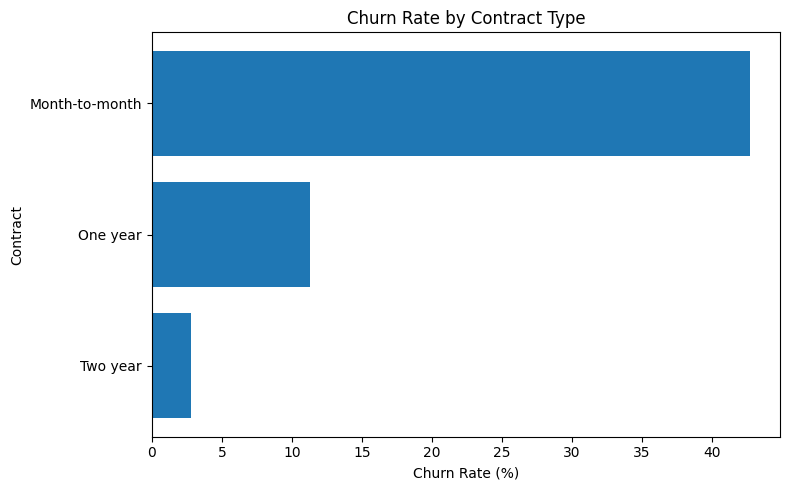

Contract
Two year           2.831858
One year          11.269518
Month-to-month    42.709677
Name: Churn, dtype: float64

In [3]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .apply(calculate_churn_rate)
      .sort_values(ascending=False)
)

print(contract_churn.round(2))

plot_churn_by_category(
    df,
    "Contract",
    "Churn Rate by Contract Type"
)


### Answer

**Month-to-month customers have the highest churn rate.** One-year and two-year contracts have substantially lower churn.

This is an association. The analysis does not prove that changing contract length would directly cause customers to stay.


# 2. Is churn higher among customers with shorter tenure?

Customers are grouped into tenure ranges to make the relationship easier to see.


TenureGroup
0-11     48.28
12-23    29.51
24-35    22.03
36-47    19.52
48-59    15.00
60+       6.68
Name: Churn, dtype: float64


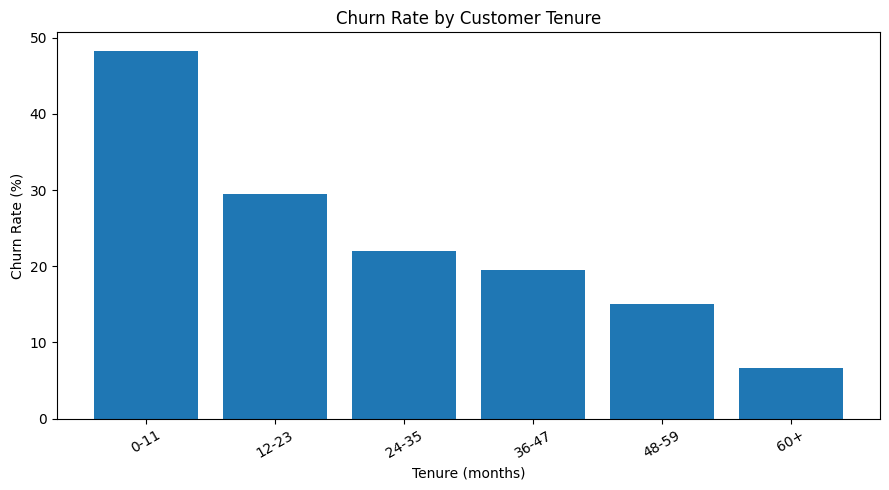

In [4]:
tenure_bins = [0, 12, 24, 36, 48, 60, float("inf")]
tenure_labels = ["0-11", "12-23", "24-35", "36-47", "48-59", "60+"]

df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    right=False,
    include_lowest=True
)

tenure_churn = (
    df.groupby("TenureGroup", observed=False)["Churn"]
      .apply(calculate_churn_rate)
)

print(tenure_churn.round(2))

plt.figure(figsize=(9, 5))
plt.bar(tenure_churn.index.astype(str), tenure_churn.values)
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Tenure")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [5]:
churn_numeric = df["Churn"].eq("Yes").astype(int)
tenure_corr = df["Tenure"].corr(churn_numeric)

print(f"Pearson correlation between Tenure and churn status: {tenure_corr:.3f}")


Pearson correlation between Tenure and churn status: -0.352


### Answer

**Yes. Churn is much higher among customers with shorter tenure.** The churn rate generally decreases as tenure increases.

The grouped rates are more informative here than relying only on a single correlation coefficient because they show how churn changes across customer-tenure ranges.


# 3. Is there a relationship between monthly charges and churn?

We compare monthly charges for customers who stayed versus customers who churned, then calculate a simple correlation with the binary churn indicator.


       count   mean  median
Churn                      
No      5174  61.27   64.43
Yes     1869  74.44   79.65
Correlation between MonthlyCharges and churn status: 0.193


/tmp/ipykernel_400/2124208447.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


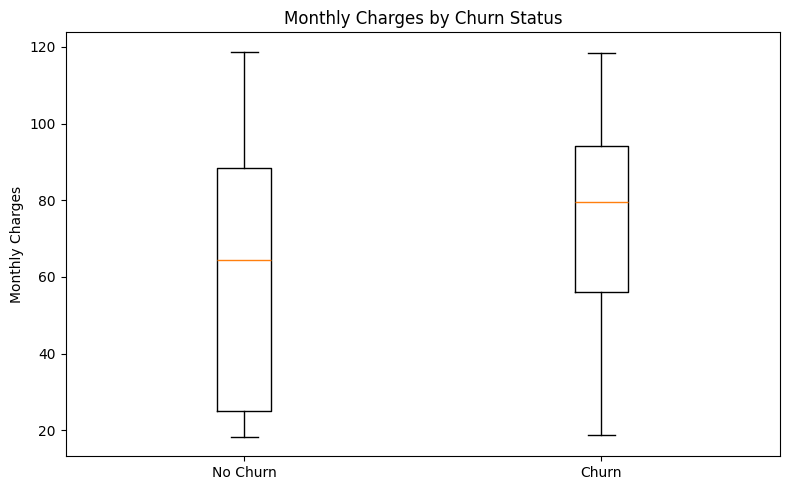

In [6]:
monthly_summary = (
    df.groupby("Churn")["MonthlyCharges"]
      .agg(["count", "mean", "median"])
      .round(2)
)

print(monthly_summary)

churn_numeric = df["Churn"].eq("Yes").astype(int)
monthly_corr = df["MonthlyCharges"].corr(churn_numeric)

print(f"Correlation between MonthlyCharges and churn status: {monthly_corr:.3f}")

plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        df.loc[df["Churn"] == "No", "MonthlyCharges"].dropna(),
        df.loc[df["Churn"] == "Yes", "MonthlyCharges"].dropna()
    ],
    labels=["No Churn", "Churn"]
)
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()


### Answer

**There is an observable association between monthly charges and churn.** Customers who churn tend to have higher monthly charges on average.

However, monthly charges are related to other factors such as the services and contracts customers have. Therefore, this should not be interpreted as "higher prices cause churn."


# 4. Which payment methods are associated with higher churn?

We calculate the churn rate for each payment method.


PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


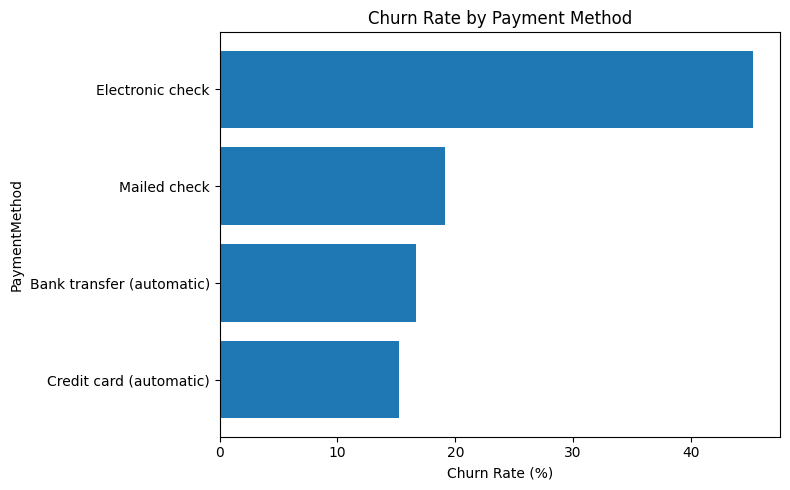

Highest churn rate: Electronic check (45.29%)


In [7]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(calculate_churn_rate)
      .sort_values(ascending=False)
)

print(payment_churn.round(2))

plot_churn_by_category(
    df,
    "PaymentMethod",
    "Churn Rate by Payment Method"
)

print(
    f"Highest churn rate: {payment_churn.index[0]} "
    f"({payment_churn.iloc[0]:.2f}%)"
)


### Answer

**Electronic check has the highest churn rate** among the payment methods in this dataset.

This is a segment-level association. Payment method may be correlated with other characteristics such as contract type, tenure, or service configuration.


# 5. Does internet service type influence churn?

We compare churn rates across the categories in `InternetService`.

The word "influence" is used in the question, but this analysis can only establish an **association**, not causation.


InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


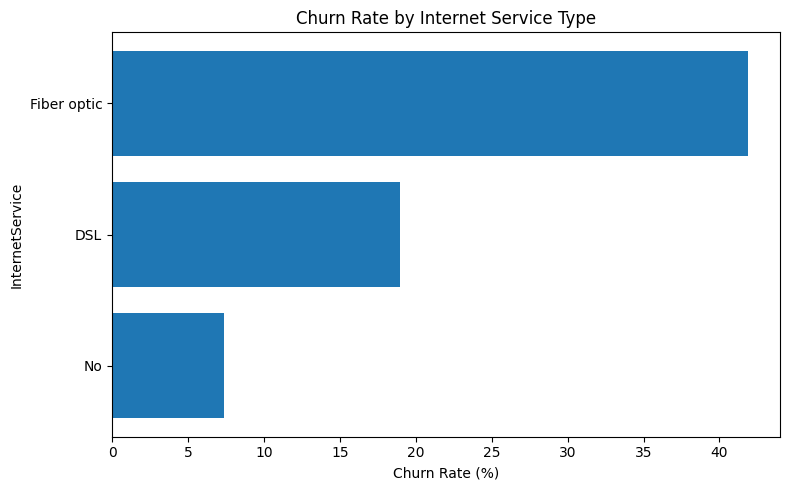

InternetService
No              7.404980
DSL            18.959108
Fiber optic    41.892765
Name: Churn, dtype: float64

In [8]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(calculate_churn_rate)
      .sort_values(ascending=False)
)

print(internet_churn.round(2))

plot_churn_by_category(
    df,
    "InternetService",
    "Churn Rate by Internet Service Type"
)


### Answer

**Internet service type is strongly associated with different churn rates.** Fiber optic customers show a substantially higher churn rate than DSL customers, while customers with no internet service show a much lower rate.

The dataset alone does not establish that internet service type itself causes churn.


# 6. Which customer services appear to be associated with lower churn?

For each service, customers with `Yes` are compared with customers with `No`.

Rows labeled `No internet service` are excluded where applicable because that category represents a different service configuration, rather than simply the absence of an add-on.


In [9]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_results = []

for service in service_columns:
    subset = df[df[service].isin(["Yes", "No"])]

    rates = (
        subset.groupby(service)["Churn"]
              .apply(calculate_churn_rate)
    )

    service_results.append({
        "Service": service,
        "With service": rates.get("Yes", float("nan")),
        "Without service": rates.get("No", float("nan")),
        "Difference (without - with)": (
            rates.get("No", float("nan")) - rates.get("Yes", float("nan"))
        )
    })

service_results = pd.DataFrame(service_results).sort_values(
    "Difference (without - with)",
    ascending=False
)

service_results.round(2)


,Service,With service,Without service,Difference (without - with)
0,OnlineSecurity,14.61,41.77,27.16
3,TechSupport,15.17,41.64,26.47
1,OnlineBackup,21.53,39.93,18.40
2,DeviceProtection,22.50,39.13,16.63
5,StreamingMovies,29.94,33.68,3.74
4,StreamingTV,30.07,33.52,3.45


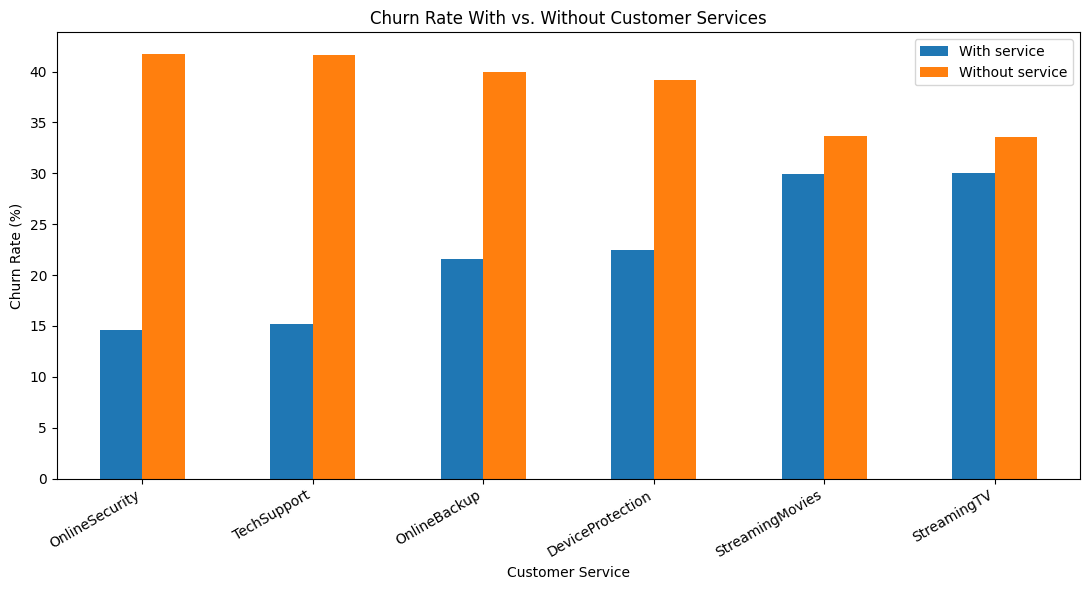

In [10]:
plot_data = service_results.set_index("Service")[[
    "With service",
    "Without service"
]]

ax = plot_data.plot(kind="bar", figsize=(11, 6))
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Customer Service")
ax.set_title("Churn Rate With vs. Without Customer Services")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Answer

**Online Security and Tech Support stand out as services associated with lower churn.** Customers who have these services tend to churn less than customers without them.

That does not prove that adding these services would reduce churn. The customers who choose these services may differ systematically from customers who do not.


# Final Conclusions

| Question | Main finding |
|---|---|
| Contract type | Month-to-month customers have the highest churn rate |
| Tenure | Churn is higher among customers with shorter tenure |
| Monthly charges | Churned customers tend to have higher monthly charges |
| Payment method | Electronic check has the highest churn rate |
| Internet service | Fiber optic customers have a higher churn rate than DSL customers |
| Customer services | Online Security and Tech Support are associated with lower churn |

## Overall interpretation

The strongest patterns in this exploratory analysis are the large differences in churn by **contract type**, **tenure**, **payment method**, and **internet service**.

These variables may also be related to one another. A stronger analysis would therefore control for multiple variables simultaneously before making business recommendations.


# Next Steps

Possible extensions:

- Statistical significance tests
- Cross-tabulation of important categorical variables
- Analysis of interactions between contract and tenure
- Logistic regression
- Customer churn prediction with machine learning
- Model evaluation using precision, recall and F1-score
- Interactive dashboard
